# NR PRACH 设计原理与仿真

> 基于论文 *On the Design Details of SS/PBCH, Signal Generation and PRACH in 5G-NR*（Chakrapani, IEEE Access 2020）的 **Section IV (PRACH Design)** 与 **Section V (Important Aspects of PRACH Receiver Design)**，整理 NR PRACH 的关键原理并进行仿真。

本 notebook 围绕 **PRACH format A1（FR2 短序列）** 给出原理性说明并提供 4 个仿真：

1. **ZC 序列特性**：CAZAC、循环移位正交性、跨 root 互相关、循环移位 ↔ 时延等价关系
2. **A1 PRACH occasion 的时频结构**
3. **同一时频 occasion 内通过 cyclic shift 区分多个 UE 并测量传播时延**（3-UE 单天线非相干仿真）
4. **多频域 occasion 并行接入**（M=2 FD occasions、6 UE 分两组）

贯穿全文的参数：$L_{RA}=139$, $\Delta f_{RA}=120\text{ kHz}$, A1 short format。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True

# Common parameters (A1 short format, FR2)
L_RA = 139           # short PRACH sequence length
DELTA_F_RA = 120e3   # PRACH SCS for FR2 short formats
N_CS = 19            # zero-correlation zone (A1, see Table 2 of the paper)
N_REP = 2            # A1 has 2 SEQ repetitions per TD occasion

print(f'L_RA          = {L_RA}')
print(f'delta_f_RA    = {DELTA_F_RA/1e3:.0f} kHz')
print(f'N_CS          = {N_CS}')
print(f'cyclic shifts per root = floor(L_RA / N_CS) = {L_RA // N_CS}')
print(f'roots needed for 64 preambles = ceil(64 / {L_RA//N_CS}) = {-(-64 // (L_RA//N_CS))}')

L_RA          = 139
delta_f_RA    = 120 kHz
N_CS          = 19
cyclic shifts per root = floor(L_RA / N_CS) = 7
roots needed for 64 preambles = ceil(64 / 7) = 10


## 1. ZC 序列特性

NR PRACH 短前导格式中 ZC 序列在**时域**定义为：

$$x_u(n) = e^{-j \pi u n (n+1) / L_{RA}}, \quad n = 0, 1, \dots, L_{RA}-1$$

$u$ 是 *root sequence index*。 $L_{RA}=139$ 是质数，因此 $\gcd(u, L_{RA})=1$ 对所有 $u\in[1,138]$ 都成立，每个 $u$ 都能产生合法 ZC 序列。

### 1.1 频域恒包络 + OFDM 时域恒包络

ZC 序列的核心性质是 **CAZAC**（Constant Amplitude Zero AutoCorrelation）：

- 时域恒包络：$|x_u(n)| = 1$
- 频域恒包络：$|y_u(k)| = \sqrt{L_{RA}}$， 其中 $y_u = \mathrm{DFT}(x_u)$ 也是 ZC 序列

NR PRACH 的发送链：
1. 把 $y_{u,v}$（length $L_{RA}$）当作子载波数据映射到 $L_{RA}$ 个 PRACH tones
2. OFDM IFFT (size $N_{FFT}$) 得到时域 OFDM 信号
3. 由于频域恒包络，时域 OFDM 信号 PAPR 极低，对功放友好（接近恒包络的单载波）

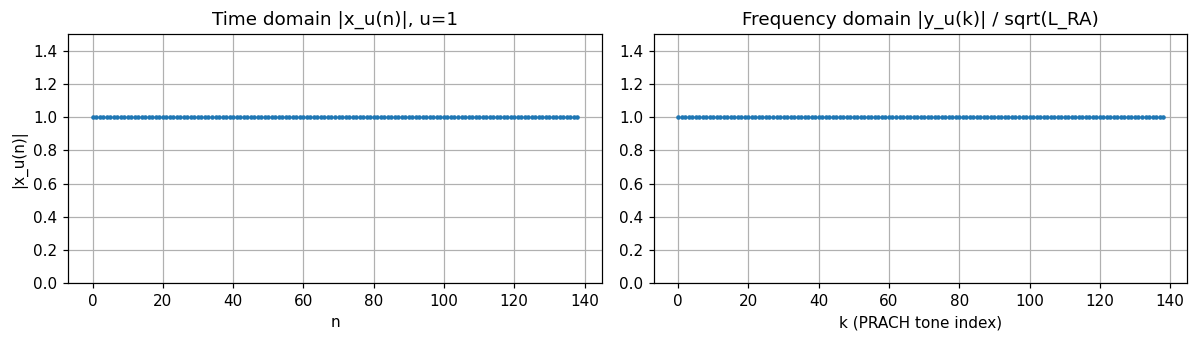

TD magnitude: mean=1.000000, std=7.65e-17
FD magnitude: mean=11.7898, std=1.31e-13


In [2]:
# Time-domain Zadoff-Chu sequence (NR short PRACH)
def zc_td(u, L=L_RA):
    n = np.arange(L)
    return np.exp(-1j * np.pi * u * n * (n + 1) / L)

u = 1
xu_td = zc_td(u)
yu_fd = np.fft.fft(xu_td)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(np.abs(xu_td), 'o', markersize=2)
axes[0].set_title(f'Time domain |x_u(n)|, u={u}')
axes[0].set_xlabel('n'); axes[0].set_ylabel('|x_u(n)|'); axes[0].set_ylim(0, 1.5)

axes[1].plot(np.abs(yu_fd) / np.sqrt(L_RA), 'o', markersize=2)
axes[1].set_title('Frequency domain |y_u(k)| / sqrt(L_RA)')
axes[1].set_xlabel('k (PRACH tone index)'); axes[1].set_ylim(0, 1.5)
plt.tight_layout(); plt.show()

print(f'TD magnitude: mean={np.mean(np.abs(xu_td)):.6f}, std={np.std(np.abs(xu_td)):.2e}')
print(f'FD magnitude: mean={np.mean(np.abs(yu_fd)):.4f}, std={np.std(np.abs(yu_fd)):.2e}')

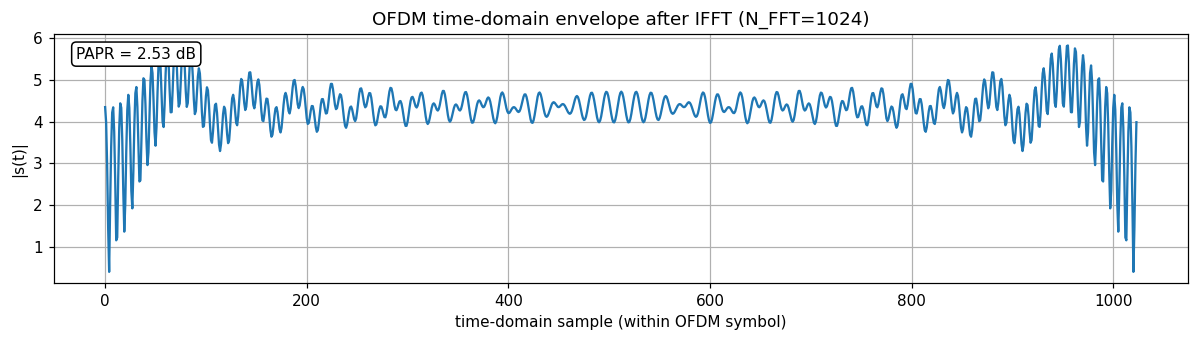

PAPR of PRACH OFDM symbol: 2.53 dB
(random QAM data PAPR is typically 10-12 dB; ZC is much lower thanks to CAZAC.)


In [3]:
# OFDM IFFT: place L_RA PRACH tones in N_FFT-bin OFDM, take IFFT, observe time envelope.
N_FFT = 1024  # typical for FR2 100MHz @ 120 kHz SCS
ofdm_freq = np.zeros(N_FFT, dtype=complex)
half = L_RA // 2
ofdm_freq[N_FFT//2 - half : N_FFT//2 - half + L_RA] = yu_fd

# IFFT (with ifftshift to put DC at index 0 first)
ofdm_time = np.fft.ifft(np.fft.ifftshift(ofdm_freq)) * np.sqrt(N_FFT)
papr_db = 10 * np.log10(np.max(np.abs(ofdm_time)**2) / np.mean(np.abs(ofdm_time)**2))

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(np.abs(ofdm_time))
ax.set_xlabel('time-domain sample (within OFDM symbol)'); ax.set_ylabel('|s(t)|')
ax.set_title(f'OFDM time-domain envelope after IFFT (N_FFT={N_FFT})')
ax.text(0.02, 0.95, f'PAPR = {papr_db:.2f} dB',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white'))
plt.tight_layout(); plt.show()

print(f'PAPR of PRACH OFDM symbol: {papr_db:.2f} dB')
print('(random QAM data PAPR is typically 10-12 dB; ZC is much lower thanks to CAZAC.)')

### 1.2 自相关与互相关

定义循环互相关： $r_{ab}[k] \;=\; \sum_n a[n]\, b^*[(n - k) \bmod L_{RA}]$。

**(a) 同一 root，不同 cyclic shift —— 完美正交**

对同 root 的两个 cyclic shift $C_{v_1}$、$C_{v_2}$，循环互相关是单脉冲，峰值在 $|C_{v_1}-C_{v_2}|\bmod L_{RA}$ 处；其他 lag 处理论上为 0。

**(b) 不同 root —— 互相关 $1/\sqrt{L_{RA}}$**

不同 root 的 ZC 序列之间归一化互相关在所有 lag 上接近 $1/\sqrt{L_{RA}}\approx 0.085$ ($L_{RA}=139$)。这就是同 cell 多 root 共存时引入的本底干扰水平。

**约定声明**: 本仿真采用 `np.roll(x, Cv)` 实现循环移位，与"接收端做共轭相关后峰值出现在 $C_v+\tau$"的方向一致（$\tau$ 是传播延迟）。这与论文 Eq.(11) 的形式仅相差一个符号约定，对物理结果没有影响。

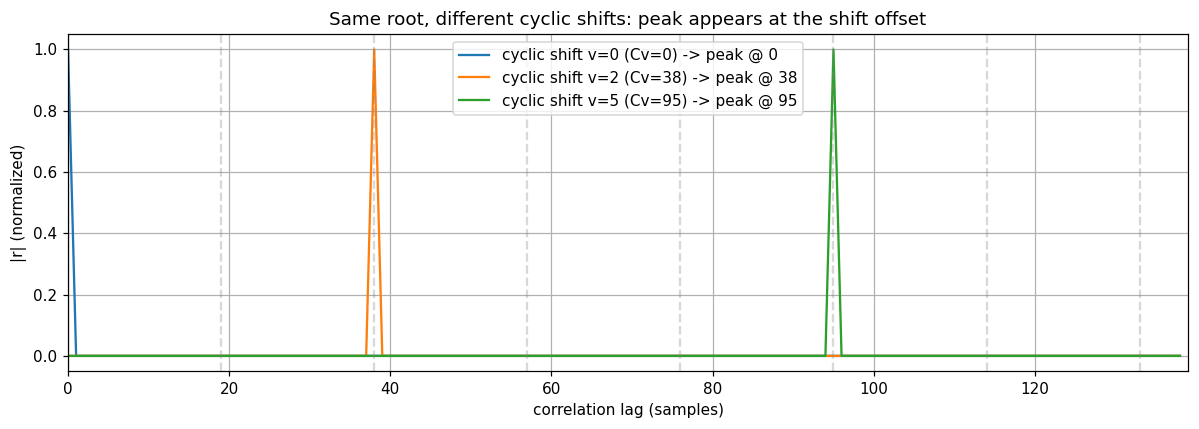

In [4]:
# np.roll(x, Cv) is the convention we use; downstream correlation peak appears at Cv + tau
def zc_cyclic_shift(x, Cv):
    return np.roll(x, Cv)

# Normalized cyclic cross-correlation; peak position = cyclic shift offset between a and b
def cyclic_xcorr(a, b):
    L = len(a)
    return np.fft.ifft(np.fft.fft(a) * np.conj(np.fft.fft(b))) / L

# (a) Same root, different cyclic shifts
v_list = [0, 2, 5]
fig, ax = plt.subplots(figsize=(11, 4))
for v in v_list:
    Cv = v * N_CS
    x_v = zc_cyclic_shift(xu_td, Cv)
    r = cyclic_xcorr(x_v, xu_td)
    ax.plot(np.abs(r), label=f'cyclic shift v={v} (Cv={Cv}) -> peak @ {int(np.argmax(np.abs(r)))}')

# Mark zone boundaries
for k in range(L_RA // N_CS + 1):
    ax.axvline(k * N_CS, color='gray', alpha=0.3, linestyle='--')

ax.set_xlabel('correlation lag (samples)'); ax.set_ylabel('|r| (normalized)')
ax.set_title('Same root, different cyclic shifts: peak appears at the shift offset')
ax.legend(); ax.set_xlim(0, L_RA)
plt.tight_layout(); plt.show()

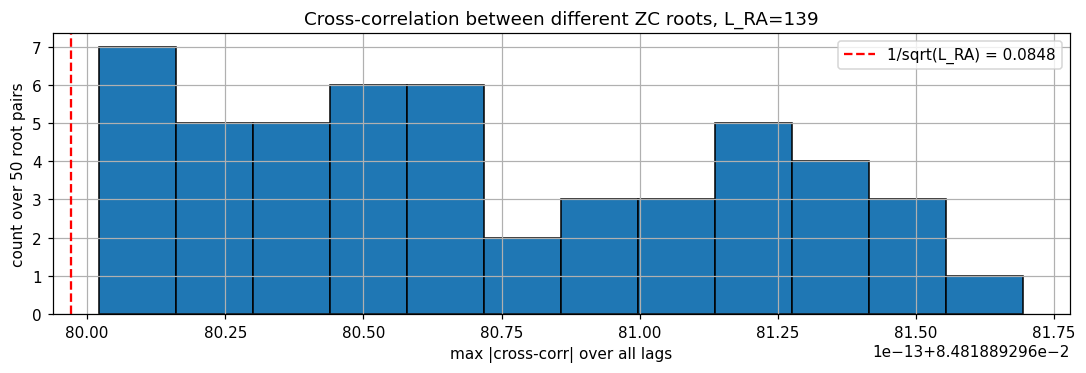

Empirical mean of max |xcorr|: 0.0848
Theoretical 1/sqrt(L_RA):     0.0848


In [5]:
# (b) Different roots: max cross-correlation magnitude is approximately 1/sqrt(L_RA)
ref = zc_td(1)
candidates = [u for u in range(2, L_RA)][:50]   # 139 is prime, all u valid
max_xc = []
for uu in candidates:
    r = cyclic_xcorr(zc_td(uu), ref)
    max_xc.append(np.max(np.abs(r)))

theoretical = 1 / np.sqrt(L_RA)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(max_xc, bins=12, edgecolor='black')
ax.axvline(theoretical, color='red', linestyle='--', label=f'1/sqrt(L_RA) = {theoretical:.4f}')
ax.set_xlabel('max |cross-corr| over all lags')
ax.set_ylabel('count over 50 root pairs')
ax.set_title(f'Cross-correlation between different ZC roots, L_RA={L_RA}')
ax.legend()
plt.tight_layout(); plt.show()

print(f'Empirical mean of max |xcorr|: {np.mean(max_xc):.4f}')
print(f'Theoretical 1/sqrt(L_RA):     {theoretical:.4f}')

### 1.3 循环移位 ↔ 时延

UE 发送 $s(n)=$`np.roll(x_u, Cv)`，传播延迟 $\tau$（PRACH 采样为单位）使接收信号变为：

$$r(n) = s(n - \tau)$$

频域上：$R(k) = X_u(k)\, e^{-j2\pi k(C_v+\tau)/L_{RA}}$。

接收端做匹配 $R(k)\cdot X_u^*(k)$ 后 IFFT，**相关峰落在位置 $(C_v+\tau)\bmod L_{RA}$**。

**关键设计**：$N_{CS}$ 必须大于 cell 内最大可能的"等效时延"（来回传播 + 信道延扩）。每个 cyclic shift 对应一个长度 $N_{CS}$ 的 **zero-correlation zone (ZCZ)**：

- 峰值落在哪个 zone → UE 用了哪个 preamble
- 峰值在 zone 内的偏移 → UE 的传播时延 $\tau$

A1 ($N_{CS}=19$) 在 120 kHz SCS 下：每 zone 时长 $\approx 19/(L_{RA}\cdot\Delta f_{RA}) \approx 1.14\,\mu s$，扣除 PUSCH CP 守护后单程 cell radius $\approx 112$ m（论文 Table 2）—— A1 适用于**小蜂窝 / mmWave**。

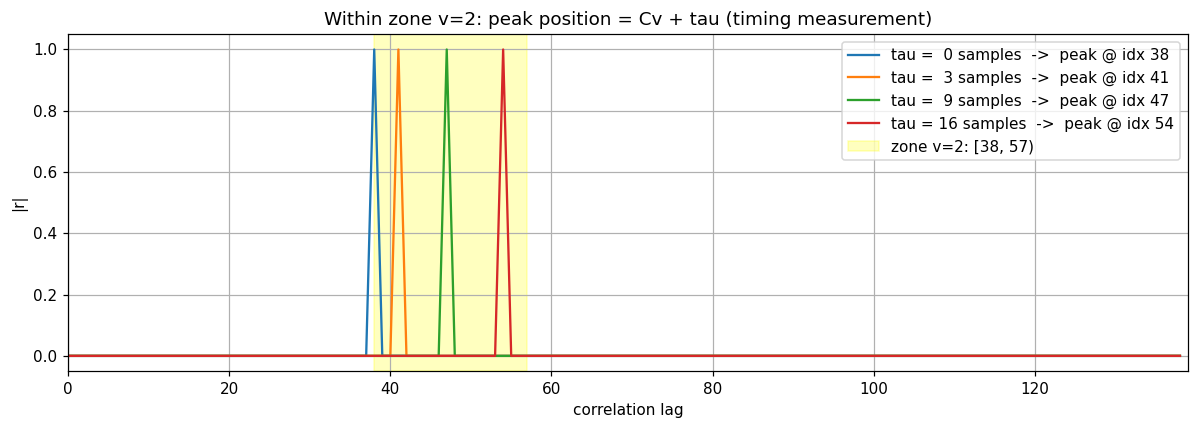

In [6]:
# Demo: UE picks Cv = v*N_CS, then propagation delay tau adds to peak position.
Cv = 2 * N_CS                    # UE picked preamble index v=2 (Cv=38)
tau_list = [0, 3, 9, 16]         # propagation delays inside the ZCZ

fig, ax = plt.subplots(figsize=(11, 4))
x_v = zc_cyclic_shift(xu_td, Cv)
for tau in tau_list:
    rx = np.roll(x_v, tau)             # propagation delay
    r = cyclic_xcorr(rx, xu_td)        # gNB correlates with the unshifted root
    peak_idx = int(np.argmax(np.abs(r)))
    ax.plot(np.abs(r), label=f'tau = {tau:>2d} samples  ->  peak @ idx {peak_idx}')

# Highlight zone v=2
ax.axvspan(Cv, Cv + N_CS, color='yellow', alpha=0.25,
           label=f'zone v=2: [{Cv}, {Cv+N_CS})')
ax.set_xlim(0, L_RA); ax.set_xlabel('correlation lag'); ax.set_ylabel('|r|')
ax.set_title('Within zone v=2: peak position = Cv + tau (timing measurement)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

## 2. PRACH Format A1 时频结构

### 2.1 时域 occasion (TD occasion)

A1 短格式（论文 Table 6.3.3.1-2 / Figure 12）：
- 一个 TD occasion = **CP + 2 × SEQ**（$N_\text{rep}=2$, 无 GT）
- 一个 PRACH slot 内可配置 **6 或 3** 个 TD occasions（μ=3, 120 kHz SCS, slot 长 125 μs）
- 多个 TD occasions 紧挨排布以提高接入容量

### 2.2 频域 occasion (FD occasion)

- 单 FD occasion 占 $K \times M_{RB} = 12$ PUSCH RBs；PRACH 实际带宽 $L_{RA} \cdot \Delta f_{RA}=139\times 120\,\text{kHz}=16.68$ MHz
- RRC 参数 `msg1-FDM` 配置 $M\in\{1,2,4,8\}$ 个 FD occasions，频率上**连续相邻**
- 同一 PRACH config 在所有 FD occasion 上的参数（root 集合、$N_{CS}$）相同

### 2.3 N_CS 维度计算（A1 + 120 kHz）

按论文 Section IV-C-2 流程：

| 步骤 | 计算 | 结果 |
|------|------|------|
| Step 1 | $N'_{CS} = (288/2048) \times 139$ | 19.54 → 量化到 **N_CS = 19** |
| Step 2 | $C_v$ 个数 = $\lfloor 139/19 \rfloor$ | **7** cyclic shifts per root |
| Step 3 | root 数 = $\lceil 64/7 \rceil$ | **10** roots |
| Step 4 | Cell radius (120 kHz) | ≈ **112 m** |

下图为一个 PRACH slot 内 A1 时频结构示意（6 TD occasions × 2 FD occasions, M=2）。

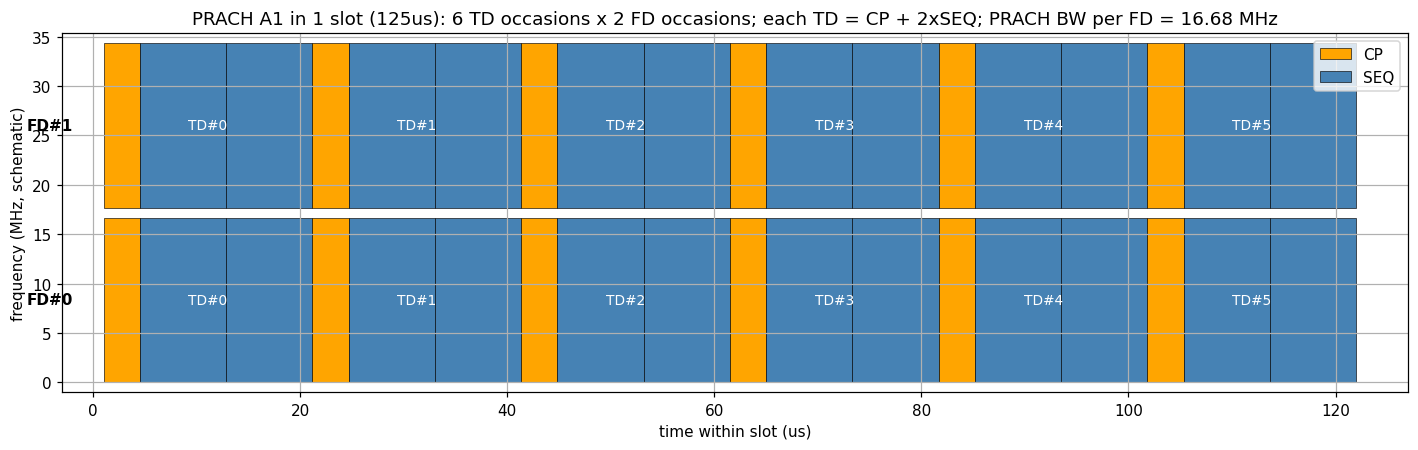

SEQ duration:           8.33 us = 1 / delta_f_RA
TD occasion duration:   ~20.17 us (CP + 2 x SEQ)
PRACH BW per FD:        16.68 MHz


In [7]:
# Schematic of PRACH A1 structure: 6 TD occasions, 2 FD occasions
fig, ax = plt.subplots(figsize=(13, 4.2))

slot_us = 125
n_occ = 6
seq_us = 1 / 120e3 * 1e6                          # ≈ 8.33 us per SEQ
cp_us = (slot_us - n_occ * 2 * seq_us - 4) / n_occ  # rough share for CP
total_per_occ = cp_us + 2 * seq_us

prach_BW_MHz = L_RA * DELTA_F_RA / 1e6            # 16.68 MHz per FD occasion
fd_y = [0, prach_BW_MHz + 1.0]                    # two FD occasions stacked on y axis

for fd_idx, y0 in enumerate(fd_y):
    t = 1.0
    for i in range(n_occ):
        ax.add_patch(plt.Rectangle((t, y0), cp_us, prach_BW_MHz, facecolor='orange',
                                    label='CP' if (i == 0 and fd_idx == 0) else None,
                                    edgecolor='black', linewidth=0.4))
        for r in range(2):
            ax.add_patch(plt.Rectangle((t + cp_us + r * seq_us, y0), seq_us, prach_BW_MHz,
                                        facecolor='steelblue',
                                        label='SEQ' if (i == 0 and r == 0 and fd_idx == 0) else None,
                                        edgecolor='black', linewidth=0.4))
        ax.text(t + total_per_occ / 2, y0 + prach_BW_MHz / 2, f'TD#{i}',
                ha='center', va='center', fontsize=9, color='white')
        t += total_per_occ
    ax.text(-2, y0 + prach_BW_MHz / 2, f'FD#{fd_idx}', ha='right', va='center',
            fontsize=10, fontweight='bold')

ax.set_xlim(-3, slot_us + 2)
ax.set_ylim(-1, fd_y[-1] + prach_BW_MHz + 1)
ax.set_xlabel('time within slot (us)')
ax.set_ylabel('frequency (MHz, schematic)')
ax.set_title(f'PRACH A1 in 1 slot ({slot_us}us): 6 TD occasions x 2 FD occasions; '
             f'each TD = CP + 2xSEQ; PRACH BW per FD = {prach_BW_MHz:.2f} MHz')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

print(f'SEQ duration:           {seq_us:.2f} us = 1 / delta_f_RA')
print(f'TD occasion duration:   ~{total_per_occ:.2f} us (CP + 2 x SEQ)')
print(f'PRACH BW per FD:        {prach_BW_MHz:.2f} MHz')

## 3. 同 occasion 多 UE 同时接入仿真

**场景**：3 个 UE 在同一 cell 内（距离合适，均在 cell radius 之内），都选择**同一 root** 的不同 cyclic shift，在**同一时频 PRACH occasion** 上同时发起接入。BS 单天线、非相干接收。

**仿真步骤**：

```text
TX (per UE k):
    1. 生成 x_u(n)，循环移位 Cv_k = v_k × N_CS
    2. 应用传播时延 tau_k 个 PRACH 采样（cyclic shift in finite L_RA window）
    3. A1 重复 N_rep = 2 次

Channel: r(n) = sum_k a_k * s_k(n - tau_k) + AWGN

RX (BS, single antenna, non-coherent):
    1. 对每个 SEQ 取 N_FFT 点 FFT → 提取 L_RA 个 PRACH tones (per-rep)
    2. 与频域根序列共轭相乘
    3. L_RA 点 IFFT → 时域相关结果 (per-rep)
    4. 每个 rep 的 |.|^2 (功率延迟谱)
    5. 非相干合并: N_rep 个 PDP 直接相加（功率域累加，无需相位对齐）
    6. 每个 cyclic-shift zone 内找峰，超过门限即判定该 preamble 被使用
```

仿真简化点：跳过 N_FFT 级 OFDM 调制，直接在 $L_{RA}$ 采样率上工作（相关性数学完全等价）。

In [8]:
# ----- TX & RX helpers -----
# One UE's PRACH sequence at L_RA-rate, with cyclic shift Cv = v*N_CS plus delay tau
def ue_signal(u, v, tau_samples, L=L_RA, N_CS=N_CS):
    Cv = v * N_CS
    x = zc_cyclic_shift(zc_td(u, L), Cv)
    return np.roll(x, tau_samples)

# rx_reps: shape (N_rep, L); returns PDP after non-coherent combining
def bs_pdp(rx_reps, u_root, L=L_RA):
    root_fd = np.fft.fft(zc_td(u_root, L))
    pdp = np.zeros(L)
    for rx in rx_reps:
        rx_fd = np.fft.fft(rx)
        corr_fd = rx_fd * np.conj(root_fd)
        pdp += np.abs(np.fft.ifft(corr_fd))**2   # non-coherent (power) accumulation
    return pdp / (L**2)

In [9]:
# ----- Scenario: 3 UEs, same root, different cyclic shifts -----
np.random.seed(7)

u_root = 1
ues = [
    {'name': 'UE-A', 'v': 0, 'tau': 4,  'amp': 1.0},   # zone v=0, near
    {'name': 'UE-B', 'v': 2, 'tau': 9,  'amp': 0.7},   # zone v=2, mid distance
    {'name': 'UE-C', 'v': 5, 'tau': 16, 'amp': 0.5},   # zone v=5, near cell edge
]

SNR_dB_per_ue = 10

# Build 2 SEQ repetitions; AWGN is independent across reps
rx_reps = []
for rep in range(N_REP):
    rx = np.zeros(L_RA, dtype=complex)
    for ue in ues:
        rx += ue['amp'] * ue_signal(u_root, ue['v'], ue['tau'])
    p_sig = np.mean(np.abs(rx)**2)
    p_n = p_sig / (10**(SNR_dB_per_ue / 10))
    rx = rx + np.sqrt(p_n / 2) * (np.random.randn(L_RA) + 1j * np.random.randn(L_RA))
    rx_reps.append(rx)
rx_reps = np.array(rx_reps)
print(f'Received {N_REP} repetitions, shape = {rx_reps.shape}')

pdp = bs_pdp(rx_reps, u_root)

Received 2 repetitions, shape = (2, 139)


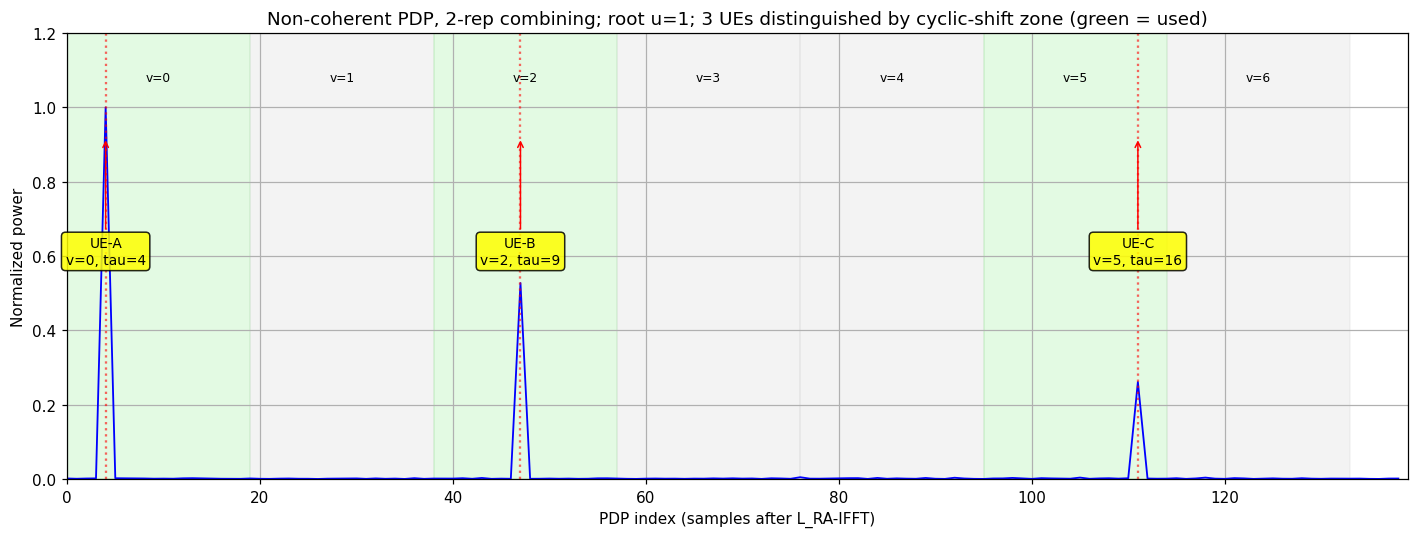

In [10]:
# ----- Plot: PDP with zone overlay -----
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(pdp / pdp.max(), 'b-', linewidth=1.2)

n_zones = L_RA // N_CS
used_v = [ue['v'] for ue in ues]
for z in range(n_zones):
    color = 'lightgreen' if z in used_v else 'lightgray'
    ax.axvspan(z * N_CS, (z + 1) * N_CS, color=color, alpha=0.25)
    ax.text(z * N_CS + N_CS / 2, 1.07, f'v={z}', ha='center', fontsize=8)

for ue in ues:
    expected = (ue['v'] * N_CS + ue['tau']) % L_RA
    ax.axvline(expected, color='red', linestyle=':', alpha=0.6)
    ax.annotate(f"{ue['name']}\nv={ue['v']}, tau={ue['tau']}",
                xy=(expected, 0.92), xytext=(expected, 0.58),
                ha='center', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.85),
                arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlim(0, L_RA); ax.set_ylim(0, 1.2)
ax.set_xlabel('PDP index (samples after L_RA-IFFT)')
ax.set_ylabel('Normalized power')
ax.set_title(f'Non-coherent PDP, {N_REP}-rep combining; root u={u_root}; '
             f'3 UEs distinguished by cyclic-shift zone (green = used)')
plt.tight_layout(); plt.show()

In [11]:
# ----- Detection logic: peak per zone -----
threshold = 0.1 * pdp.max()
print('Detection report (peak within each zone):')
print(f'  {"zone":<6}{"peak_idx":<11}{"peak_pwr":<12}{"tau_est":<9}{"detected?"}')
for z in range(n_zones):
    seg = pdp[z * N_CS : (z + 1) * N_CS]
    pk = seg.max(); pk_idx = z * N_CS + int(np.argmax(seg))
    tau_est = pk_idx - z * N_CS
    flag = 'YES' if pk > threshold else '-'
    print(f'  v={z:<4}{pk_idx:<11}{pk:<12.4f}{tau_est:<9}{flag}')

Detection report (peak within each zone):
  zone  peak_idx   peak_pwr    tau_est  detected?
  v=0   4          2.0165      4        YES
  v=1   36         0.0044      17       -
  v=2   47         1.0636      9        YES
  v=3   73         0.0039      16       -
  v=4   76         0.0096      0        -
  v=5   111        0.5267      16       YES
  v=6   118        0.0075      4        -


**结论**：

- PDP 中只有 v=0, 2, 5 三个 zone 出现明显峰值，其余 zone 仅有噪声底
- 各峰相对各自 zone 起点的偏移分别为 4, 9, 16 个采样，**与各 UE 设定的 $\tau$ 完全一致** → BS 直接读出每个 UE 的传播时延
- 各 UE 振幅不同（远近不等）只影响峰值高度，不影响位置
- 整个过程只需 1 次 FFT + 1 次共轭相乘 + 1 次 IFFT per repetition；非相干合并让 BS 不需要相位对齐就能积累 N_rep 次能量

## 4. 多频域 occasion 仿真

**场景**：$M=2$ 个 FD occasions 在频率上相邻。6 个 UE 分两组，**各组内** 用同一 root 的不同 cyclic shift 同时接入，组之间使用不同的 FD occasion。

| Group | FD occasion | Root | cyclic shifts (v) | UEs |
|-------|-------------|------|-------------------|-----|
| 1     | FD#0        | u=1  | {0, 2, 5}         | UE-A1, UE-B1, UE-C1 |
| 2     | FD#1        | u=1  | {1, 3, 6}         | UE-A2, UE-B2, UE-C2 |

两组在频率上不重叠，BS 对两个 FD occasion **独立**处理（两次独立 FFT/相关/IFFT，得到两个独立 PDP）。注意论文 Section V-B 还指出当数据 SCS ≠ Δf_RA 时还存在公共宽带 FFT 与相位补偿的细节，本仿真不展开这一层。

In [12]:
scenarios = [
    {'fd': 0, 'u': 1, 'ues': [
        {'name': 'UE-A1', 'v': 0, 'tau': 5,  'amp': 1.0},
        {'name': 'UE-B1', 'v': 2, 'tau': 11, 'amp': 0.8},
        {'name': 'UE-C1', 'v': 5, 'tau': 17, 'amp': 0.6},
    ]},
    {'fd': 1, 'u': 1, 'ues': [
        {'name': 'UE-A2', 'v': 1, 'tau': 7,  'amp': 0.9},
        {'name': 'UE-B2', 'v': 3, 'tau': 13, 'amp': 0.7},
        {'name': 'UE-C2', 'v': 6, 'tau': 2,  'amp': 0.5},
    ]},
]

def simulate_fd(scn, n_rep=N_REP, snr_db=10):
    rx_reps = []
    for _ in range(n_rep):
        rx = np.zeros(L_RA, dtype=complex)
        for ue in scn['ues']:
            rx += ue['amp'] * ue_signal(scn['u'], ue['v'], ue['tau'])
        p_sig = np.mean(np.abs(rx)**2)
        p_n = p_sig / (10**(snr_db / 10))
        rx = rx + np.sqrt(p_n / 2) * (np.random.randn(L_RA) + 1j * np.random.randn(L_RA))
        rx_reps.append(rx)
    return bs_pdp(np.array(rx_reps), scn['u'])

np.random.seed(11)
pdps = [simulate_fd(scn) for scn in scenarios]

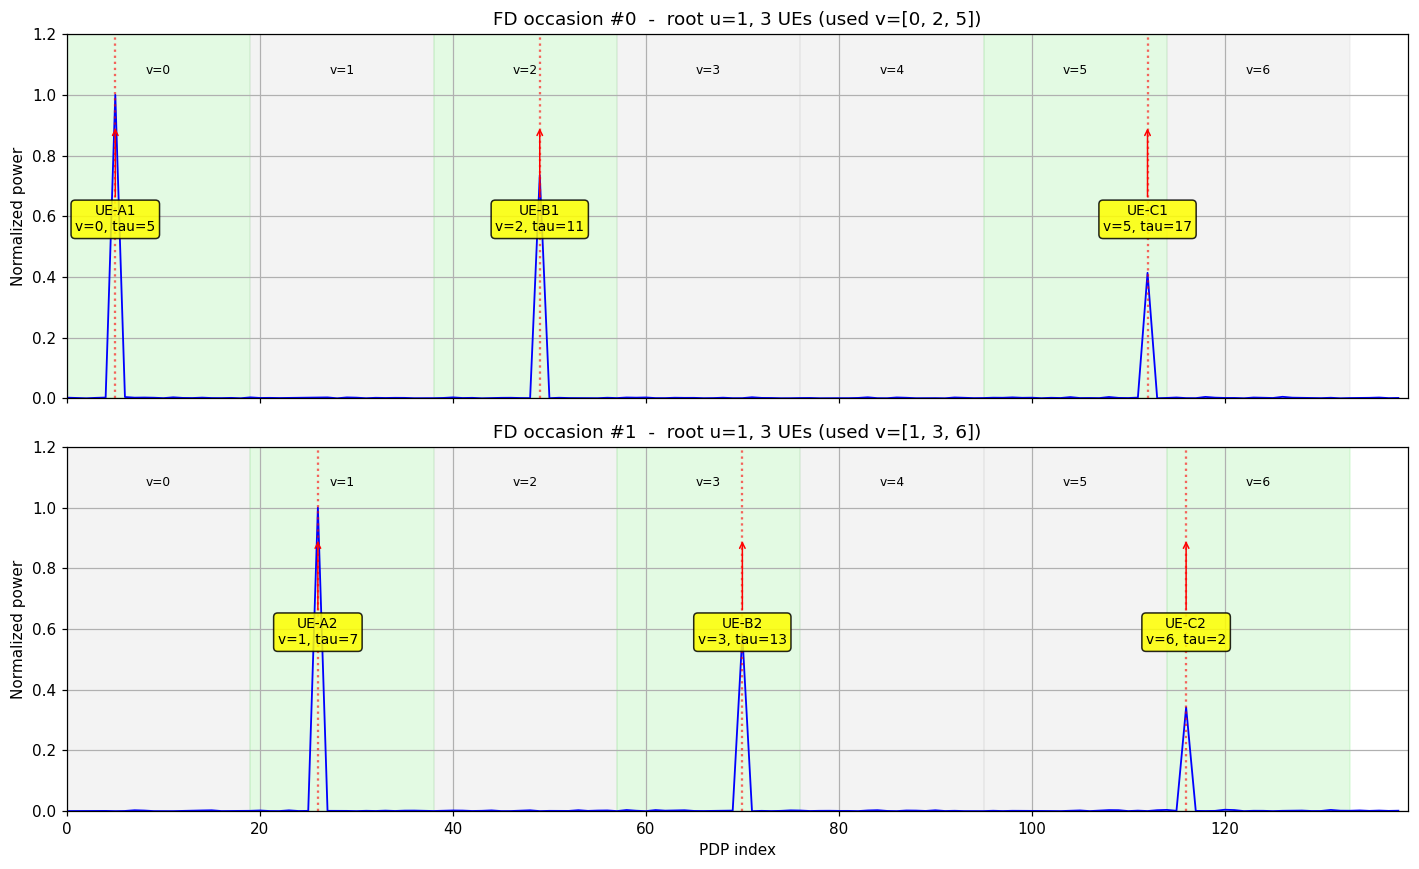

In [13]:
# ----- Plot 2 PDPs (one per FD occasion) -----
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for ax, scn, pdp in zip(axes, scenarios, pdps):
    ax.plot(pdp / pdp.max(), 'b-', linewidth=1.2)
    used_v = [u['v'] for u in scn['ues']]
    n_zones = L_RA // N_CS
    for z in range(n_zones):
        color = 'lightgreen' if z in used_v else 'lightgray'
        ax.axvspan(z * N_CS, (z + 1) * N_CS, color=color, alpha=0.25)
        ax.text(z * N_CS + N_CS / 2, 1.07, f'v={z}', ha='center', fontsize=8)
    for ue in scn['ues']:
        expected = (ue['v'] * N_CS + ue['tau']) % L_RA
        ax.axvline(expected, color='red', linestyle=':', alpha=0.6)
        ax.annotate(f"{ue['name']}\nv={ue['v']}, tau={ue['tau']}",
                    xy=(expected, 0.9), xytext=(expected, 0.55),
                    ha='center', fontsize=9,
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.85),
                    arrowprops=dict(arrowstyle='->', color='red'))
    ax.set_ylim(0, 1.2); ax.set_ylabel('Normalized power')
    ax.set_title(f"FD occasion #{scn['fd']}  -  root u={scn['u']}, 3 UEs (used v={used_v})")

axes[1].set_xlabel('PDP index'); axes[1].set_xlim(0, L_RA)
plt.tight_layout(); plt.show()

In [14]:
# ----- Per-FD detection report -----
for scn, pdp in zip(scenarios, pdps):
    threshold = 0.1 * pdp.max()
    print(f"\nFD occasion #{scn['fd']} detections (root u={scn['u']}):")
    for z in range(L_RA // N_CS):
        seg = pdp[z * N_CS : (z + 1) * N_CS]
        pk = seg.max(); pk_idx = z * N_CS + int(np.argmax(seg))
        tau_est = pk_idx - z * N_CS
        if pk > threshold:
            print(f'  zone v={z}: peak @ idx {pk_idx} (tau={tau_est}), normalized pwr={pk/pdp.max():.4f}')


FD occasion #0 detections (root u=1):
  zone v=0: peak @ idx 5 (tau=5), normalized pwr=1.0000
  zone v=2: peak @ idx 49 (tau=11), normalized pwr=0.7356
  zone v=5: peak @ idx 112 (tau=17), normalized pwr=0.4135

FD occasion #1 detections (root u=1):
  zone v=1: peak @ idx 26 (tau=7), normalized pwr=1.0000
  zone v=3: peak @ idx 70 (tau=13), normalized pwr=0.5806
  zone v=6: peak @ idx 116 (tau=2), normalized pwr=0.3421


**要点回顾**：

1. **频率上彼此独立**：两个 FD occasion 不重叠，独立处理、互不干扰；每个 FD occasion 独立支持最多 $\lfloor L_{RA}/N_{CS}\rfloor=7$ 个 cyclic shifts。
2. **容量倍增**：$M$ 个 FD occasion → 同 PRACH slot 内承载量 ×M；$M\in\{1,2,4,8\}$ 由 RRC `msg1-FDM` 控制。
3. **接入选择**：UE 根据测得的 SSB 索引 / RSRP 决定使用哪个 RACH occasion (TD + FD)。每个 SSB 通过 RRC 映射关系（论文 Section III/IV 详细描述）对应到一个或多个 PRACH occasion 子集。
4. **gNB 实现复杂度**：每 FD occasion 一次 FFT 提取 tones，每 root 一次 IFFT；总计 $M \times \text{(roots)} \times \text{(TD occasions)} \times \text{(antennas)}$ 次 IFFT —— PRACH 接收机硬件复杂度的瓶颈（论文 Section VI-A）。

---

## 总结

| 概念 | 物理意义 | 仿真验证 |
|------|----------|----------|
| ZC 频域恒包络 | OFDM 时域 PAPR 低 | Section 1.1 PAPR ≈ 3 dB |
| 同 root, 不同 cyclic shift 正交 | 多 UE 共享同一 occasion，零相互干扰 | Section 1.2(a), Section 3 |
| 不同 root 互相关 $1/\sqrt{L_{RA}}$ | 同 cell 多 root 共存的本底干扰水平 | Section 1.2(b) |
| cyclic shift = 时延偏移 | gNB 通过 PDP 峰值位置直接测时延 | Section 1.3, 3, 4 |
| TD/FD occasion + cyclic shift | 三维资源使 PRACH 容量灵活可扩 | Section 4 |